# California Housing Price Prediction using Machine Learning

This project aims to build a robust, end-to-end Machine Learning pipeline to predict housing prices in California using various regression models. It includes detailed EDA, preprocessing, model training, evaluation, and deployment using Flask.

---

## Project Overview

- Dataset: California Housing Dataset (`housing.csv`)
- Algorithms used: Linear Regression, Ridge, Lasso, Random Forest, XGBoost
- Evaluation Metrics: MAE, RMSE, R²
- Deployment: Flask web application with saved `joblib` model

---

## Author Information

- **Name:** Muhammad Tayyab  
- **Student ID:** P229279  
- **University:** FAST-NUCES (National University of Computer and Emerging Sciences)  
- **Campus:** PWR (Peshawar Campus)  
- **Email:** `p229279@pwr.nu.edu.pk`  
- **Department:** BS Artificial Intelligence

---

## Directory Structure
project-root/ │ <br>
  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;├── data/ # Raw dataset (housing.csv) <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
              ├── src/ # Notebooks, scripts <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
              ├── app/ # Flask application <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
              ├── models/ # Saved .pkl model files <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
              ├── requirements.txt # Python dependencies <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
              └── README.md # Project documentation



# **Importing  Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression ,Ridge,Lasso
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
import missingno as msno

In [6]:
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(
    style="whitegrid",      
    palette="pastel",       
    font_scale=1.2,        
    rc={                    
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "legend.frameon": False
    }
)


mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'figure.autolayout': True
})



In [7]:
df=pd.read_csv("../data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
df.shape

(20640, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# **Data Preprocessing**

In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

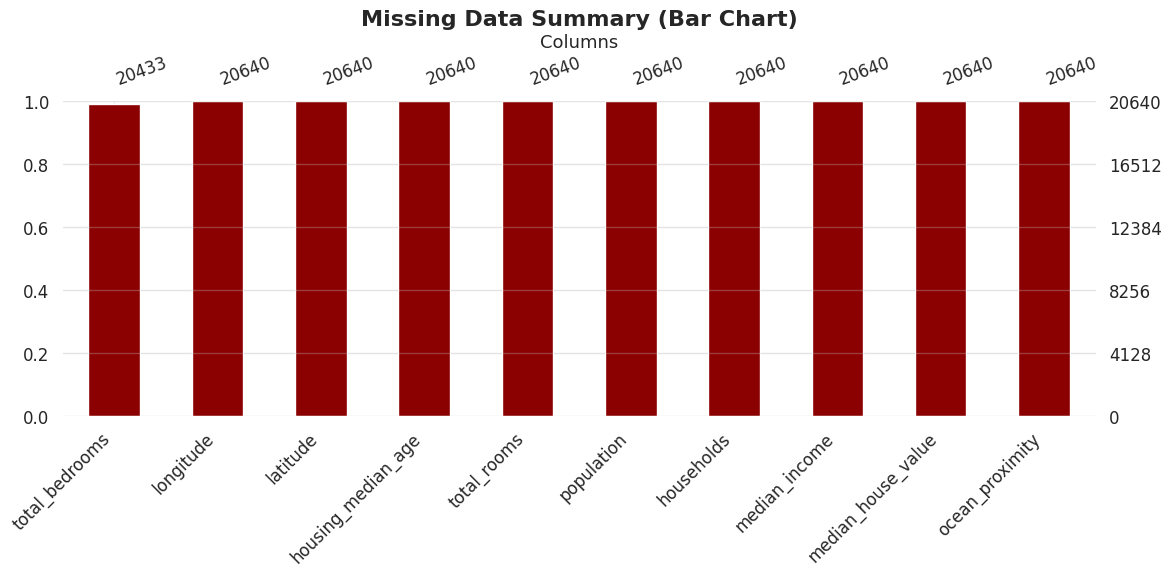

In [12]:
plt.figure(figsize=(8, 5))
msno.bar(df, 
         color='darkred', 
         sort='ascending', 
         figsize=(12, 6), 
         fontsize=12, 
         labels=True
)

plt.title("Missing Data Summary (Bar Chart)", fontsize=16, fontweight='bold')
plt.xlabel("Columns", fontsize=13)
plt.ylabel("Non-Null Count", fontsize=13)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [13]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

In [14]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# **Exploratory Data Analysis (EDA)**

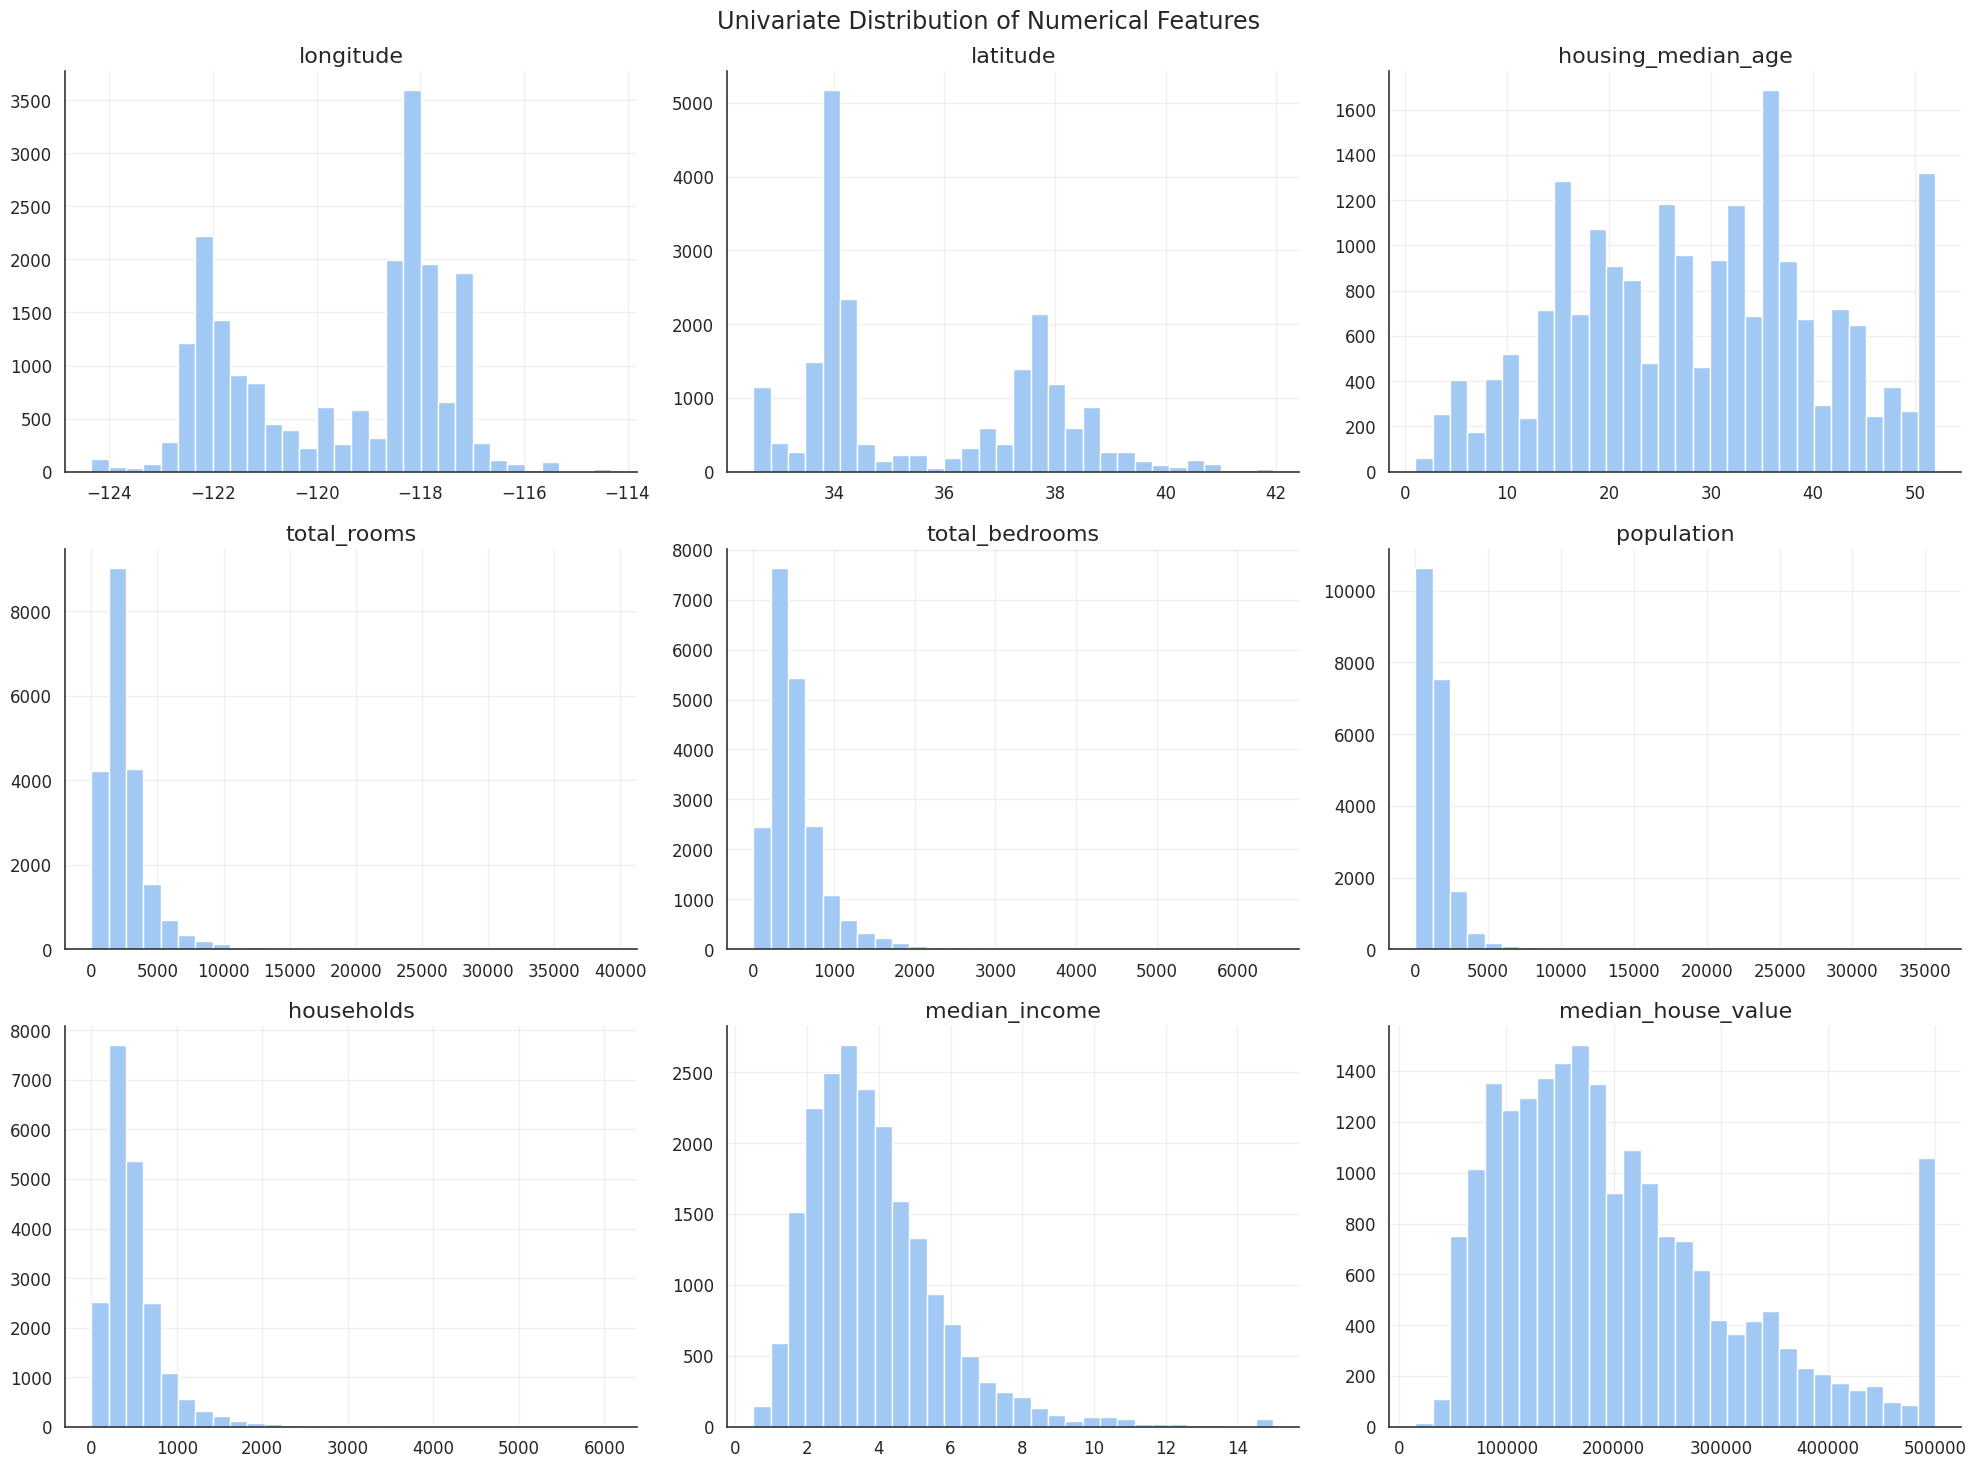

In [15]:
df.hist(bins=30, figsize=(20,15))
plt.suptitle('Univariate Distribution of Numerical Features')
plt.savefig("hist")
plt.show()

### **Observations**
Most features such as total_rooms, total_bedrooms, population, and households exhibit severe right-skewness, which may negatively impact models like linear regression or KNN that are sensitive to feature scale. These features may benefit from log transformation or normalization.

The housing_median_age histogram shows a visible spike at age 50, which likely reflects a data collection ceiling — values above 50 may have been grouped or censored.

The median_house_value plot shows a significant accumulation at $500,000, confirming earlier findings of truncated target values, which introduces bias and limits regression range.

median_income has a relatively smooth bell-shaped distribution and is likely to be highly predictive, as seen in previous scatterplots.

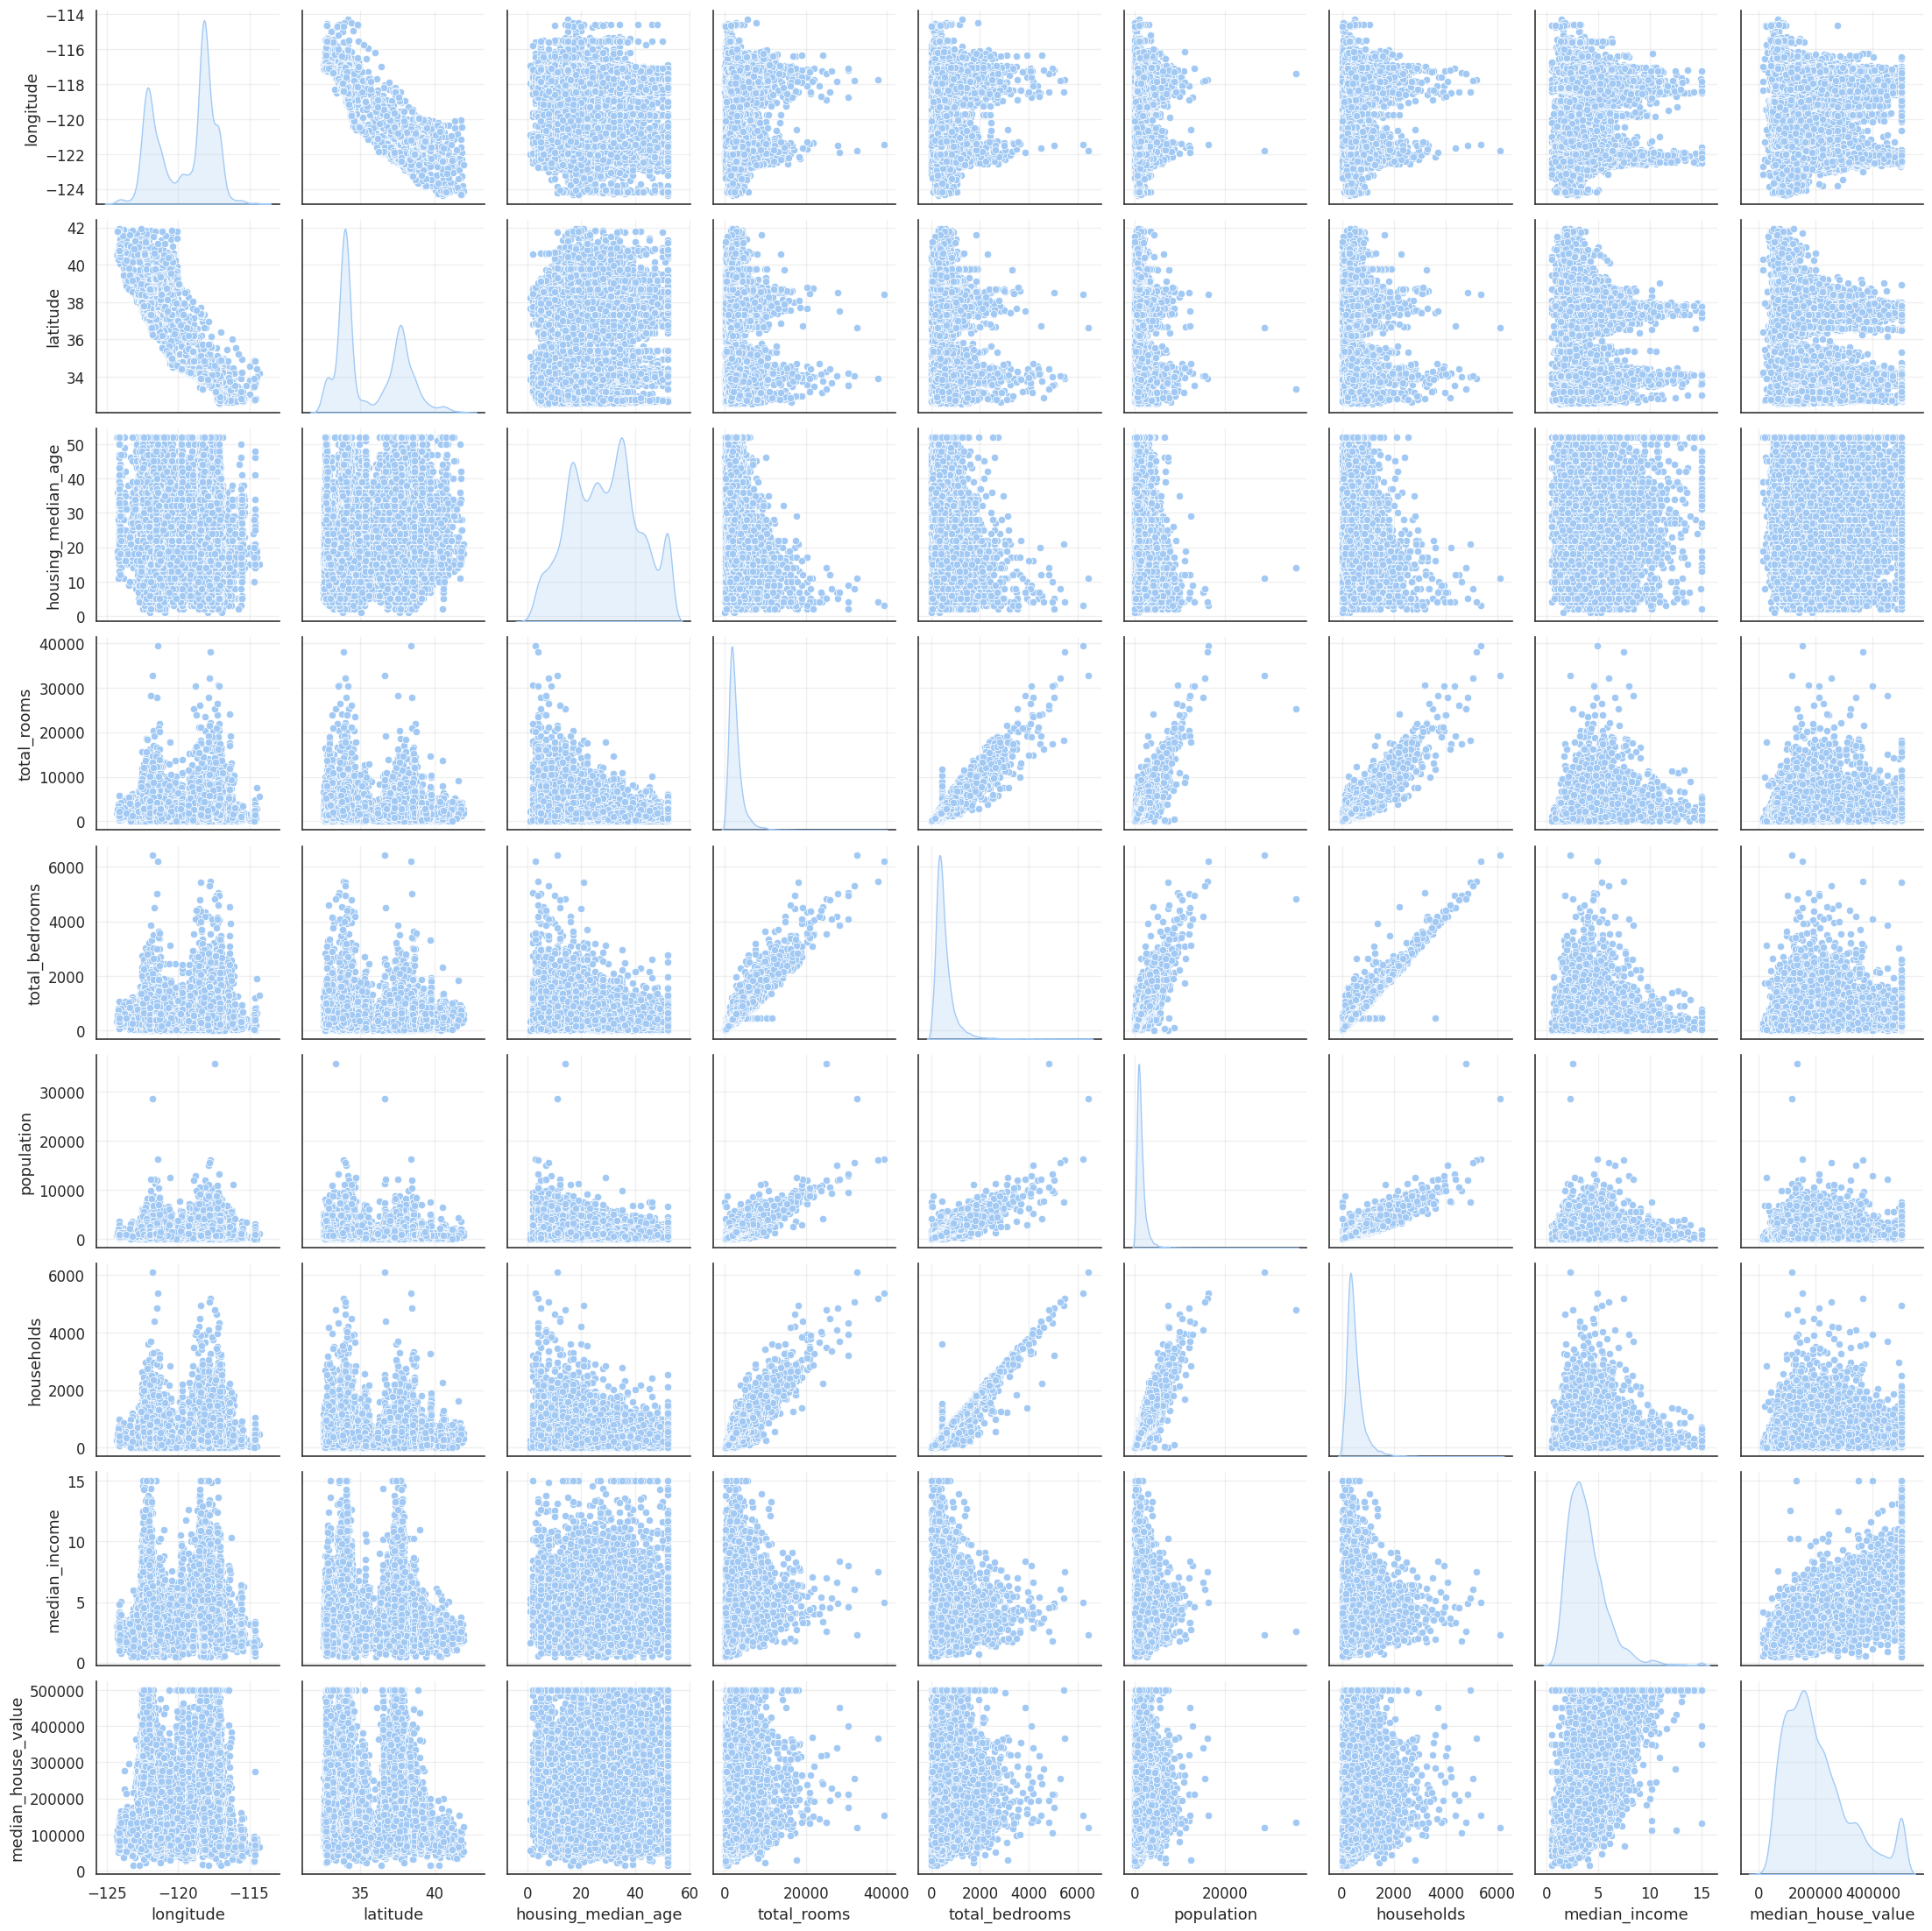

In [16]:
sns.pairplot(df, diag_kind='kde')
plt.show()

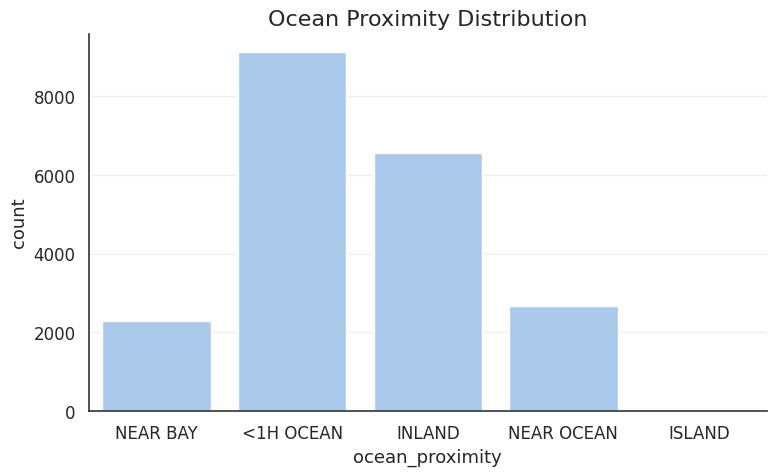

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='ocean_proximity', 
    data=df
)
plt.title('Ocean Proximity Distribution')
plt.show()

### **Observations**
- `The distribution of the ocean_proximity variable is highly imbalanced. The majority of the data points fall under the <1H OCEAN and INLAND categories, indicating that most homes are either moderately close to the coast or further inland.`

- `Categories like NEAR BAY and NEAR OCEAN are moderately represented, while ISLAND is extremely rare, making it a potential candidate for grouping into an “Other” class or being excluded from modeling altogether.`


Understanding this distribution is crucial before applying one-hot encoding, as rare categories can lead to sparse, noisy features.

- **Heatmap**

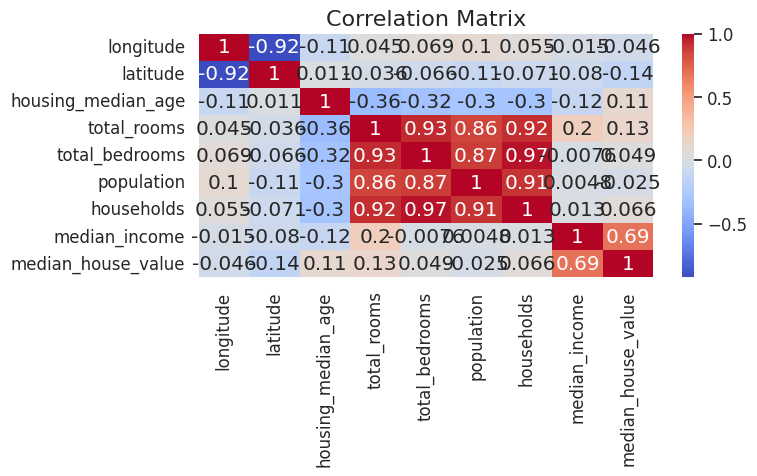

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.select_dtypes(include=['float64', 'int64']).corr(), 
    annot=True, 
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

- **Longtude & Latitude Vs Median House Value**

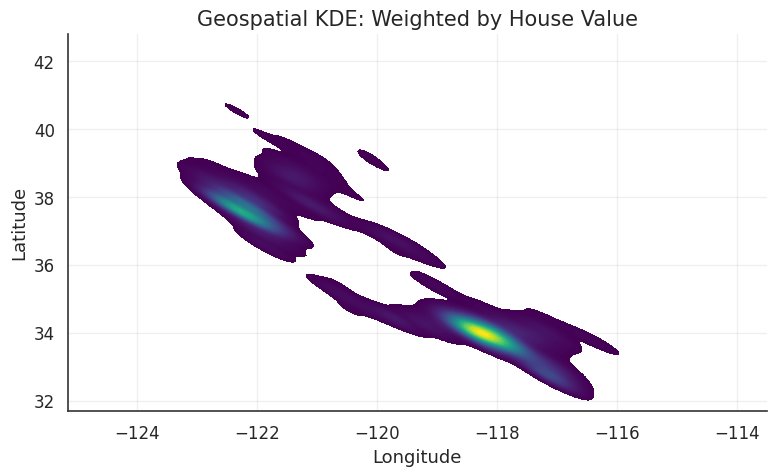

In [19]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x='longitude',
    y='latitude',
    weights=df['median_house_value'],
    cmap='viridis',
    fill=True,
    thresh=0.05,
    levels=100,
    bw_adjust=0.7
)
plt.title('Geospatial KDE: Weighted by House Value', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### **Obsevations**

`This KDE plot reveals the spatial distribution of expensive real estate in California.`

Two distinct high-density price zones stand out:

- The first hotspot is around Southern California (longitude ≈ –118), corresponding to Los Angeles and Orange County, where house prices are highest and density is substantial.

- The second major cluster appears around San Francisco Bay Area (longitude ≈ –122), known for premium coastal housing and high-income tech-driven regions.

- Inland and northern areas show very limited presence or lower house values, with price-weighted density falling rapidly.

This confirms that geographical location is a dominant predictor of housing prices, with coastal urban centers concentrating most of the expensive properties.

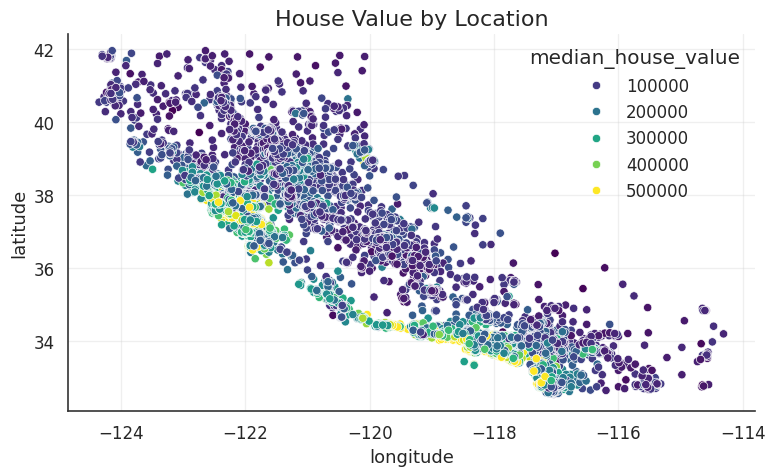

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='median_house_value', 
    palette='viridis', 
    data=df
)
plt.title('House Value by Location')
plt.show()

### **Observations**
`This geographic scatterplot of longitude vs latitude, colored by median_house_value, reveals strong location-based patterns in housing prices.`
Higher house values (yellow points) are concentrated along the California coast, especially in major urban regions like Los Angeles, San Francisco, and San Diego.


In contrast, inland and northern regions tend to have significantly lower property values, confirming that proximity to the coast is a major driver of housing prices.
This spatial pattern aligns well with the ocean_proximity variable, and highlights location as a critical feature in price prediction.

- **Housing Median Age Vs Median House Value**

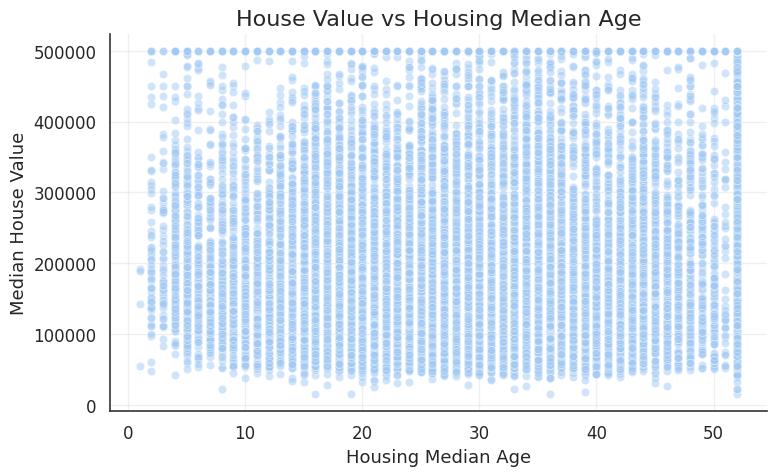

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='housing_median_age', 
    y='median_house_value', 
    data=df, 
    alpha=0.5
)
plt.title('House Value vs Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.show()

### **Observations**

`There is no clear linear relationship between housing_median_age and median_house_value.`

Houses of all ages — both newer and older — appear across a wide price range.
Notably, many properties show an age of exactly 50 years, indicating a data cap or grouping (possibly “50+” as max recorded value).

Additionally, the horizontal line at $500,000 again suggests a ceiling effect in house values, as discussed previously.


`This plot suggests that age alone is not a strong predictor of house value in this dataset.`

- **Total Rooms  Vs Median House Value**

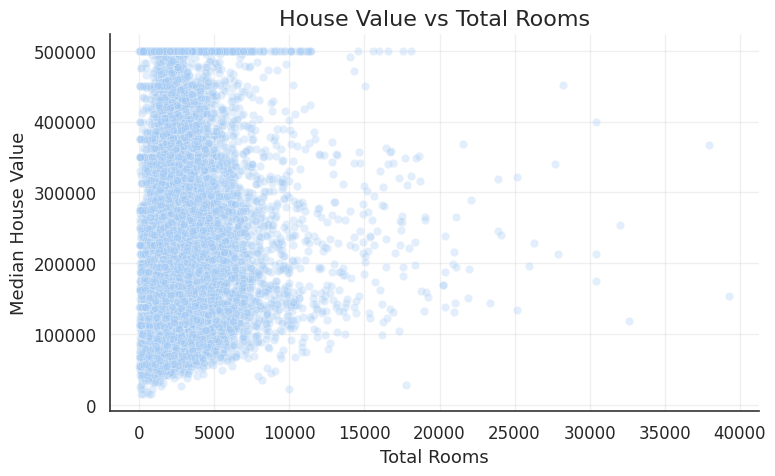

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='total_rooms', 
    y='median_house_value', 
    data=df, 
    alpha=0.3
)
plt.title('House Value vs Total Rooms')
plt.xlabel('Total Rooms')
plt.ylabel('Median House Value')
plt.show()

### **Observation**

`While total_rooms increases, there is no clear upward trend in median_house_value.`

In fact, many homes with a large number of rooms still have relatively low prices — indicating that room count alone is not a good predictor of house price.


There is a high concentration of homes with room counts under 10,000, and a few extreme outliers beyond 20,000 rooms which may represent large apartment buildings or data entry errors.


Once again, the horizontal strip at $500,000 confirms a capping effect in house values.
This plot also suggests that derived features (like rooms_per_household) may be more meaningful than raw room counts.

- **Total Bedrooms Vs Median House Value**

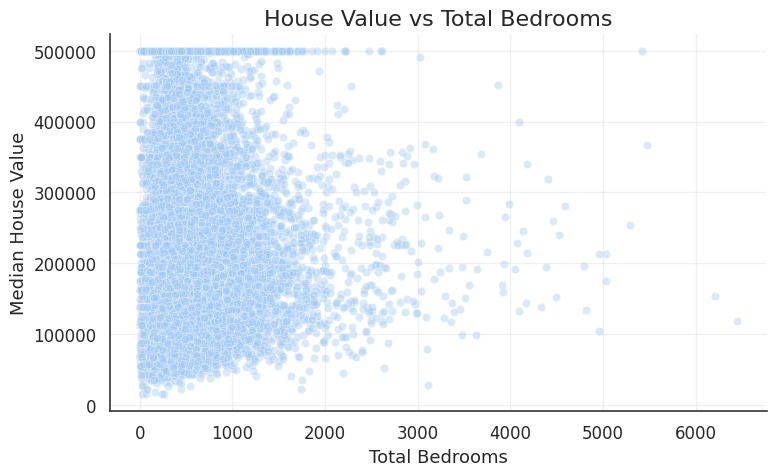

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='total_bedrooms', 
    y='median_house_value', 
    data=df, 
    alpha=0.4
)
plt.title('House Value vs Total Bedrooms')
plt.xlabel('Total Bedrooms')
plt.ylabel('Median House Value')
plt.show()

### **Observation**

`The scatterplot of total_bedrooms vs median_house_value shows a weak and noisy relationship between the number of bedrooms and house price.`


Most houses have fewer than 2000 bedrooms, and even those with a high bedroom count do not necessarily have high values, indicating that bedroom count alone is not a strong price predictor.


There are a few extreme outliers beyond 3000–6000 bedrooms, which likely correspond to large residential complexes or data anomalies.
The persistent horizontal cap at $500,000 again confirms the upper bound imposed in the dataset.


This supports the use of engineered ratios (e.g., bedrooms_per_room) over raw bedroom count for modeling.



- **Population Vs Median House Value**

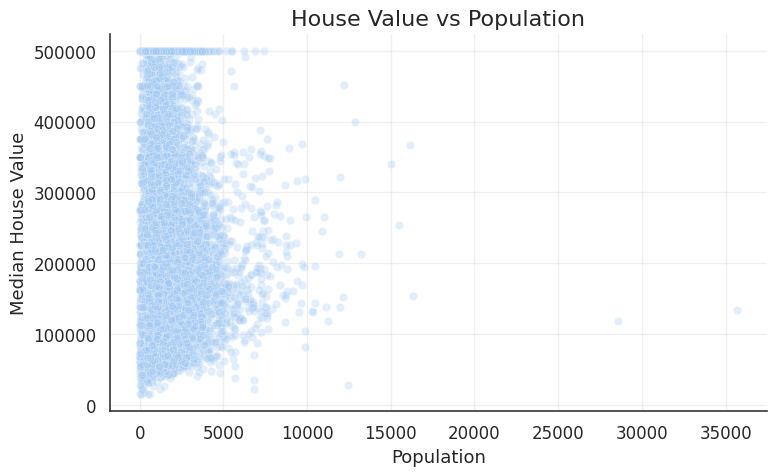

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='population', 
    y='median_house_value', 
    data=df, 
    alpha=0.3)
plt.title('House Value vs Population')
plt.xlabel('Population')
plt.ylabel('Median House Value')
plt.show()

### **Observation**


`The scatterplot shows no strong correlation between population and median_house_value.`

House values remain widely spread across population sizes, indicating that population alone does not drive housing prices in this dataset.
Most data points fall below 5000 in population, with a few extreme outliers exceeding 20,000 — these could represent urban centers, dense blocks, or misreported data.


The horizontal cap at $500,000 persists, reflecting the known upper-bound truncation of house values.
For modeling, this suggests that population may only be useful in combination with other features (like households or density).

- **Household Vs Median House Value**

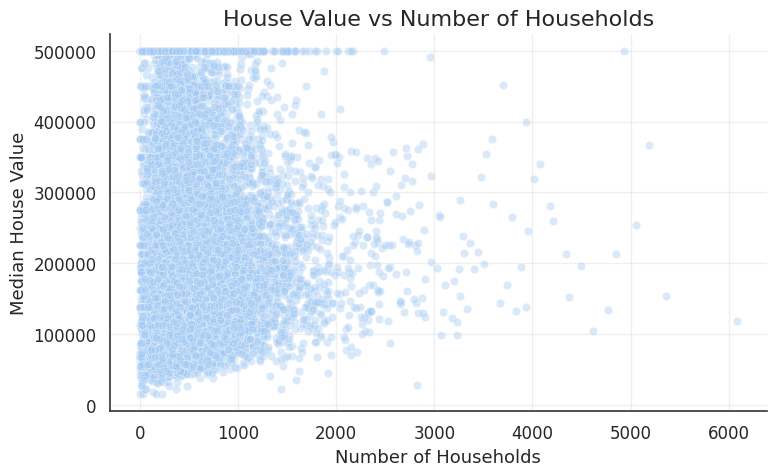

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='households', 
    y='median_house_value', 
    data=df, 
    alpha=0.4
)
plt.title('House Value vs Number of Households')
plt.xlabel('Number of Households')
plt.ylabel('Median House Value')
plt.show()


### **Observation**

`The number of households does not exhibit a strong linear relationship with median_house_value.`

Most housing blocks have fewer than 2000 households, and within this range, house values vary significantly.

There are a few extreme outliers exceeding 5000 households — likely representing densely populated urban neighborhoods, large complexes, or census blocks with high vertical living.


Once again, the horizontal capping at $500,000 is evident, confirming the dataset's upper-value truncation.


Although not useful on its own, households may contribute better predictive power when used in engineered ratios, such as rooms_per_household or population_per_household.

- **Median income Vs Median House Value**

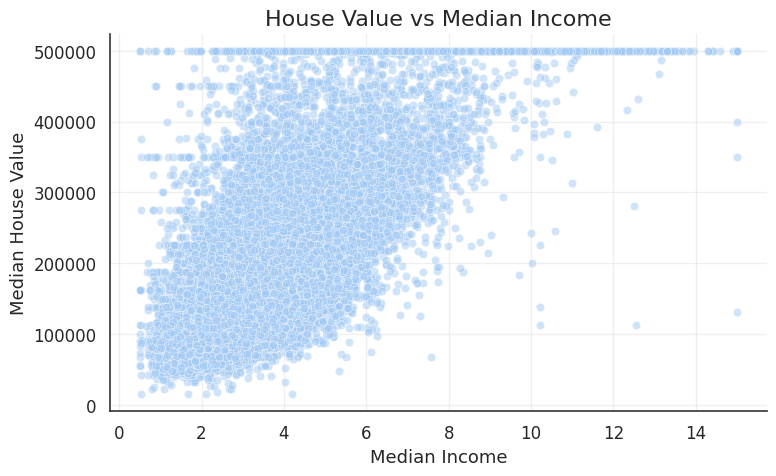

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='median_income', 
    y='median_house_value', 
    data=df, 
    alpha=0.5
)
plt.title('House Value vs Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

### **Observation**

`There is a strong positive correlation between median_income and median_house_value, indicating that areas with higher incomes generally have more expensive homes.`


However, a horizontal band at $500,000 is clearly visible, revealing a capping effect in the data. This suggests that many house values were truncated at the upper limit of $500,000, likely due to a data collection ceiling.
This artificial limit may underrepresent true house values for high-income areas and could introduce bias during model training if not handled carefully.

- **Ocean Proximity Vs Median House Value**

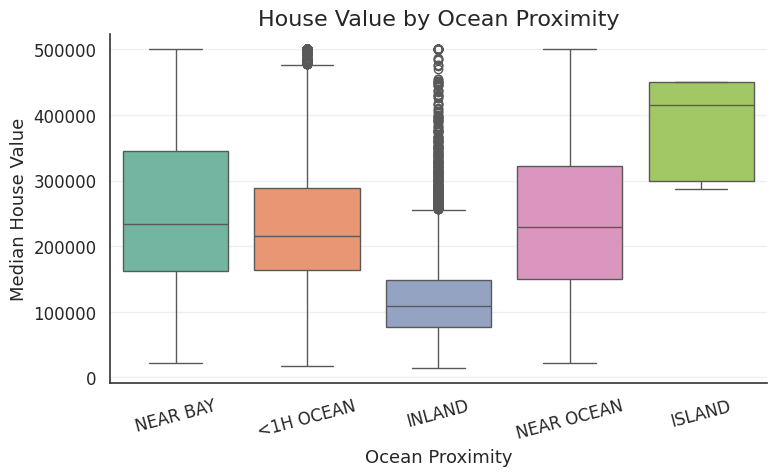

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='ocean_proximity', 
    y='median_house_value', 
    data=df, 
    palette='Set2'
)
plt.title('House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.xticks(rotation=15)
plt.show()


`The ocean_proximity feature shows a clear and significant influence on median_house_value.`

- Houses located INLAND have the lowest median values, with tight IQR and many lower outliers.

- The <1H OCEAN and NEAR OCEAN categories have higher medians and broader price distributions.

- NEAR BAY properties also show strong value potential, second only to ISLAND homes.

- ISLAND properties, although rare, display consistently high values with very few outliers — possibly due to luxury or vacation zones.

The $500,000 cap is again evident as many outliers are squashed at the top.

This plot confirms that proximity to water is a powerful predictor of housing price in California and should be retained as a categorical feature.

# **Data Preprocessing Version 2**

- **Outlier Handling**

In [28]:

def clip_outliers_iqr(df, columns, factor=1.5):
    df_clipped = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        df_clipped[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"Clipped outliers in {col}: outside [{lower_bound:.2f}, {upper_bound:.2f}]")
    return df_clipped


In [29]:
outlier_cols = ['total_rooms', 'total_bedrooms', 'population', 'households']
df = clip_outliers_iqr(df, outlier_cols)


Clipped outliers in total_rooms: outside [-1102.62, 5698.38]
Clipped outliers in total_bedrooms: outside [-222.38, 1162.62]
Clipped outliers in population: outside [-620.00, 3132.00]
Clipped outliers in households: outside [-207.50, 1092.50]


In [30]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,5698.375,1106.0,2401.0,1092.5,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


- **Pipeline Creation**

In [31]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['median_house_value']).columns.tolist()
cat_cols = ['ocean_proximity']

In [32]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [33]:
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [34]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [35]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

In [38]:
results = []


for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

In [39]:
results_df = pd.DataFrame(results).set_index('Model')
print("\nModel Performance:")
display(results_df.style.format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'R²': '{:.4f}'}))


Model Performance:


,MAE,RMSE,R²
Model,,,
Linear,"49,534.53","68,174.33",0.6647
Ridge,"49,536.45","68,175.04",0.6647
Lasso,"49,534.77","68,174.45",0.6647
RandomForest,"31,957.40","49,487.71",0.8233
XGBoost,"35,405.83","51,962.90",0.8052


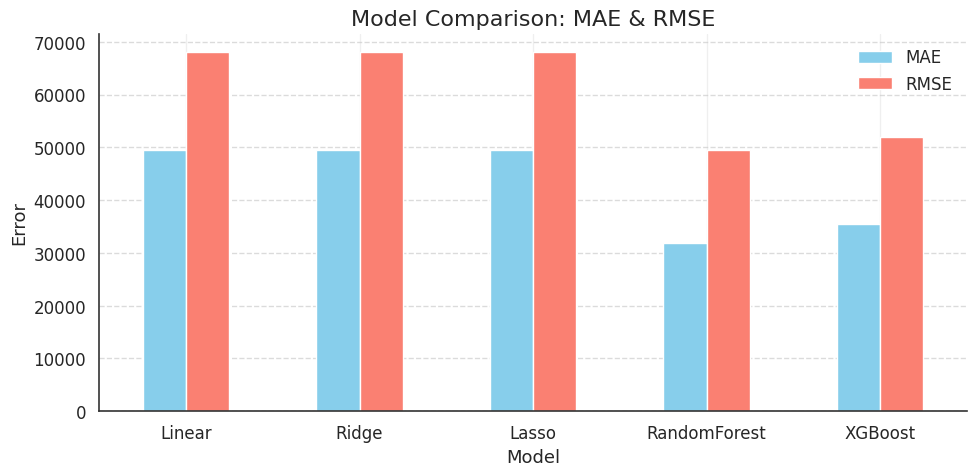

In [40]:
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 5), color=['skyblue', 'salmon'])
plt.title('Model Comparison: MAE & RMSE')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()





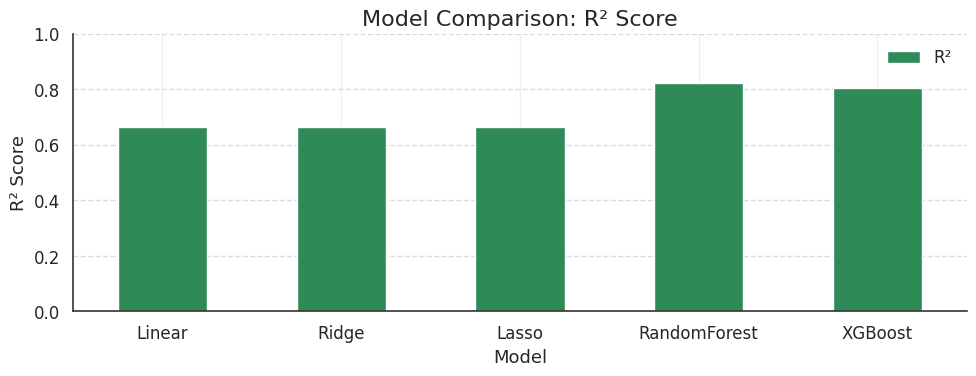

In [41]:
results_df[['R²']].plot(kind='bar', figsize=(10, 4), color='seagreen')
plt.title('Model Comparison: R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor())
    ])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
    
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"MAE  (Mean Absolute Error):      {mae:,.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse:,.2f}")
print(f"R²   (R-squared Score):          {r2:.4f}")


Model Evaluation Metrics:
MAE  (Mean Absolute Error):      32,011.69
RMSE (Root Mean Squared Error):  49,698.44
R²   (R-squared Score):          0.8218


In [50]:
joblib.dump(pipeline, '../models/house_price_predictor.pkl')

['../models/house_price_predictor.pkl']

In [53]:
def predict_price(input_data):
    model = joblib.load('../models/house_price_predictor.pkl')
    if isinstance(input_data, dict):
        input_data = pd.DataFrame([input_data])
    return model.predict(input_data)

In [54]:
sample = X_test.iloc[[0]]  
print("Predicted price:", predict_price(sample)[0])


Predicted price: 89078.0


In [56]:
pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
pipeline.fit(X_train, y_train)

    

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('regressor', LinearRegression())])

In [57]:
joblib.dump(pipeline, '../models/house_price_predictor.pkl')

['../models/house_price_predictor.pkl']